# Gruppo 2613
- Giacomo Bregolin 2188429
- Leonardo Fardin
- Lara Fogarolo 2199475
- Francesco Peron 2185610

In [3]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14

import keras_tuner
import keras
import tensorflow as tf
import tensorflow.random as tf_r
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input
%run plot.py

2026-03-19 15:05:11.210204: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Read Data

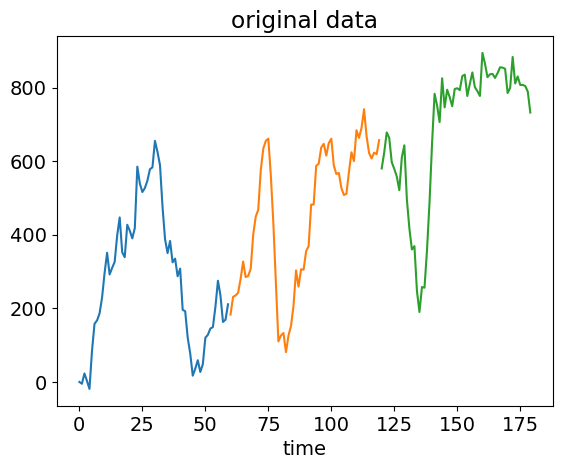

data:  10000


In [4]:
str0 = 'ts_L60_Z12_A500_DX50_bias5_N10000.dat'
fnamex='DATA/x_'+str0
fnamey='DATA/y_'+str0

x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
# number of samples, number of features
N,L = len(x), len(x[0])

Show_data(x,L,"original data")

categ = np.loadtxt(fnamey, dtype=int)
n_class = 3    # y.argmax() - y.argmin() +1
print('data: ',N)

y = np.zeros((N,n_class))
for i in range(N):
    y[i][categ[i]] = 1. # y contains one-hot encoding

## Split train-validation and rescale

(8000, 60)
N_train= 8000   N_val= 2000   L= 60   n_class= 3
std_train average and mean: 588.25397835931 44.84287073276593 201.46657645528722
std_val average and mean: 569.9090424503428 55.06717110341998 201.92178219610327


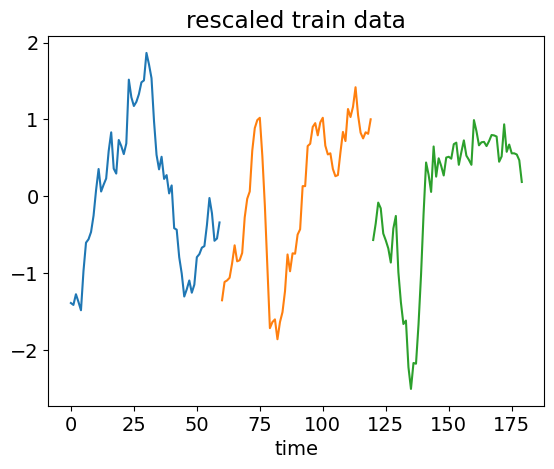

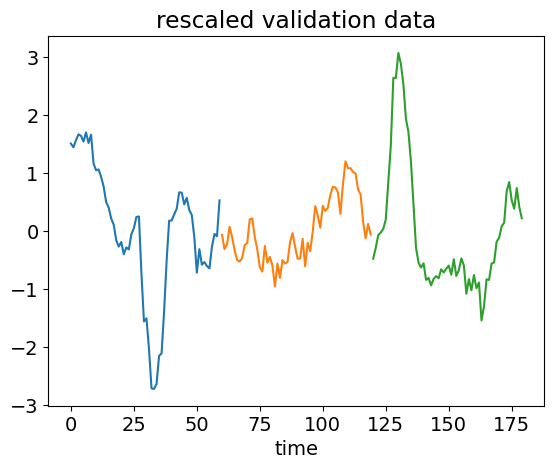

In [5]:
# split into training and validation sets
perc_train=0.8
N_train = int(perc_train*N)
x_train = x[:N_train]
print(x_train.shape)
y_train = y[:N_train]
x_val = x[N_train:]
y_val = y[N_train:]
N_val = len(x_val)
print('N_train=',N_train,'  N_val=',N_val,'  L=',L,'  n_class=',n_class)

 
#remove average value of each sample from its values
xm_train = x_train.mean(axis=1)
std_train = x_train.std(axis=1)
xm_val = x_val.mean(axis=1)
std_val = x_val.std(axis=1)
print('std_train average and mean:',max(std_train), min(std_train), std_train.mean(axis=0))
print('std_val average and mean:',max(std_val), min(std_val), std_val.mean(axis=0))

# rescale with variance on the training set
for i in range(N_train):
    #x_train[i] = (x_train[i]-xm_train[i])/ std_train[i] #not good, std_train is very variable across samples
     #x_train[i] = (x_train[i]-xm_train[i])/ 400 #crude rescaling, variance should be used
     x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
for i in range(N_val):
    #x_val[i] = (x_val[i]-xm_val[i])/ std_val[i]
    #x_val[i] = (x_val[i]-xm_val[i])/ 400
    x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)
#

    
Show_data(x_train,L,"rescaled train data")
Show_data(x_val,L,"rescaled validation data")

#x_train=x_train.astype("float32")
#y_train=y_train.astype("float32")
#x_val=x_val.astype("float32")
#y_val=y_val.astype("float32")

# Keras wants an additional dimension with a 1 at the end
x_train = x_train.reshape(x_train.shape[0], L, 1)
x_val =  x_val.reshape(x_val.shape[0], L, 1)
input_shape = (L, 1) # number of features, number of channels (1 for 1D data)

## CNN

In [6]:
# ...LESSON ...
# reproducibility
np.random.seed(12345)
import tensorflow.random as tf_r
tf_r.set_seed(12345)

## from keras import regularizers, initializers

reg = tf.keras.regularizers.l2(0.2) ## raised to 0.2 the regularization strenghts
#reg = regularizers.l1(0.1)
ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, 
                                        seed=None)
NCONV = 1 #swtich between 1 and 2 CNNs
NF = 5 #number of filters

# challenge: at most 600 tunable parameters
model = Sequential()
# 
if NCONV==1:
    # -----2-----
    model.add(Conv1D(filters=NF, kernel_size=11, 
                     kernel_initializer=ini, 
                     kernel_regularizer=reg,
                     activation='relu', 
                     input_shape=input_shape))
    #model.add(MaxPooling1D(3))
    model.add(AveragePooling1D(5))
    model.add(Conv1D(filters=5, kernel_size=7, 
                     activation='relu'))
    model.add(Flatten())
    model.add(Dense(12, activation='relu'))
    model.add(Dropout(0.2))
# 
if NCONV==2:
    # -----1-----
    model.add(Conv1D(filters=NF, kernel_size=11, 
                     kernel_initializer=ini, 
                     kernel_regularizer=reg, ######## TRY WITHOUT !
                     activation='relu', input_shape=input_shape))
    #model.add(MaxPooling1D(3))
    model.add(AveragePooling1D(5))
    model.add(Flatten())
    model.add(Dense(9, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(6, activation='relu'))
    model.add(Dropout(0.2))
    #model.add(Dense(10, activation='relu'))
    #model.add(Dropout(0.3))
model.add(Dense(n_class, activation='softmax')) # softmax !

print('----- Model',NCONV,'-----')
print(model.summary())

# optimizers
# .SGD(lr=0.01, momentum=0.9, nesterov=True) # decay=1e-6,
# .RMSprop()
# .Nadam()
opt = tf.keras.optimizers.Adam()

# compile the model
# categorical_crossentropy, 3 output nodes
model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=opt,metrics=['accuracy'])

----- Model 1 -----


/home/francesco/anaconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 50, 5)          │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 10, 5)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 4, 5)           │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │           252 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            39 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531 (2.07 KB)

 Trainable params: 531 (2.07 KB)

 Non-trainable params: 0 (0.00 B)

None


# Point 2

# Point 3

We created our model where we can choose them lambda and the regularizers, while also varying the learnig rate and the optimizier. Number of filters stays the same.

We then search for the best hyperparameters and show how the accuracy behaves while changing the values of the parameters.

In [7]:
def build_model(hp):
    np.random.seed(12345)
    tf_r.set_seed(12345)
    
    # Search over regularization type
    reg_type = hp.Choice("reg_type", values=["l1", "l2", "l1_l2", "none"])
    
    # Search over lambda strength
    lambda_val = hp.Float("lambda", min_value=1e-4, max_value=0.5, sampling="log")
    
    # Map choice to actual regularizer
    if reg_type == "l1":
        reg = tf.keras.regularizers.l1(lambda_val)
    elif reg_type == "l2":
        reg = tf.keras.regularizers.l2(lambda_val)
    elif reg_type == "l1_l2":
        reg = tf.keras.regularizers.l1_l2(l1=lambda_val, l2=lambda_val)
    elif reg_type == "none":
        reg = None

    # actual CNN
    model = Sequential()
    
    NCONV = 1
    NF = 5
    
    
    model.add(Conv1D(filters=NF, kernel_size=11,
                     kernel_initializer=ini,
                     kernel_regularizer=reg,
                     activation='relu',
                     input_shape=input_shape))
    model.add(AveragePooling1D(5))
    model.add(Conv1D(filters=5, kernel_size=7, activation='relu'))
    model.add(Flatten())
    dense_units = hp.Int("dense_units", min_value=8, max_value=32, step=4)
    model.add(Dense(dense_units, activation='relu'))
    dropout = hp.Float("dropout_1", min_value=0.0, max_value=0.5, step=0.1)
    model.add(Dropout(dropout))


    model.add(Dense(n_class, activation='softmax'))

    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    optimizer_name = hp.Choice("optimizer", values=["adam", "sgd", "rmsprop", "nadam"])

    if optimizer_name == "adam":
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "sgd":
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == "rmsprop":
        opt = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_name == "nadam":
        opt = tf.keras.optimizers.Nadam(learning_rate=learning_rate)

    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=opt,
                  metrics=['accuracy'])
    return model

In [9]:
# TRUE if to run the search, FALSE if to egt back the results

search = True
if search:
    tuner = keras_tuner.BayesianOptimization(
        hypermodel=build_model,
        objective="val_accuracy",
        max_trials=100,
        executions_per_trial=1,
        overwrite=True,
        directory="cnn_trials",
        project_name="cnn_search"
    )
    
    tuner.search(x_train, y_train,
                 epochs=50,
                 validation_data=(x_val, y_val),
                 verbose=2)

else:
    tuner = keras_tuner.BayesianOptimization(
        hypermodel=build_model,
        objective="val_accuracy",
        max_trials=100,
        executions_per_trial=1,
        overwrite=False,
        directory="cnn_trials",
        project_name="cnn_search"
    )

# Get best hyperparameters
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best reg_strength:", best_hp.get("reg_strength"))
print("Best learning_rate:",best_hp.get("learning_rate"))
print("Best optimizer:",    best_hp.get("optimizer"))
print("Best reg_type:", best_hp.get("reg_type"))
print("Best lambda:",   best_hp.get("lambda"))

Trial 36 Complete [00h 00m 52s]
val_accuracy: 0.9075000286102295

Best val_accuracy So Far: 0.9869999885559082
Total elapsed time: 00h 32m 27s

Search: Running Trial #37

Value             |Best Value So Far |Hyperparameter
l1                |l1                |reg_type
0.15946           |0.0001            |lambda
8                 |32                |dense_units
0                 |0.4               |dropout_1
0.0001            |0.01              |learning_rate
nadam             |nadam             |optimizer

Epoch 1/50


/home/francesco/anaconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 - 4s - 14ms/step - accuracy: 0.3537 - loss: 1.3692 - val_accuracy: 0.3535 - val_loss: 1.2945
Epoch 2/50
250/250 - 1s - 4ms/step - accuracy: 0.3724 - loss: 1.2462 - val_accuracy: 0.3630 - val_loss: 1.2039
Epoch 3/50
250/250 - 1s - 4ms/step - accuracy: 0.4259 - loss: 1.1707 - val_accuracy: 0.4235 - val_loss: 1.1413
Epoch 4/50
250/250 - 1s - 4ms/step - accuracy: 0.4740 - loss: 1.1239 - val_accuracy: 0.4535 - val_loss: 1.1122
Epoch 5/50
250/250 - 1s - 4ms/step - accuracy: 0.4618 - loss: 1.1059 - val_accuracy: 0.4280 - val_loss: 1.1018
Epoch 6/50
250/250 - 1s - 4ms/step - accuracy: 0.4456 - loss: 1.1009 - val_accuracy: 0.4320 - val_loss: 1.1001
Epoch 7/50
250/250 - 1s - 4ms/step - accuracy: 0.3901 - loss: 1.0996 - val_accuracy: 0.4025 - val_loss: 1.0991
Epoch 8/50
250/250 - 1s - 4ms/step - accuracy: 0.3370 - loss: 1.0988 - val_accuracy: 0.3335 - val_loss: 1.0987
Epoch 9/50
250/250 - 1s - 4ms/step - accuracy: 0.3268 - loss: 1.0987 - val_accuracy: 0.3335 - val_loss: 1.0987
Epoch 10/50

KeyboardInterrupt: 

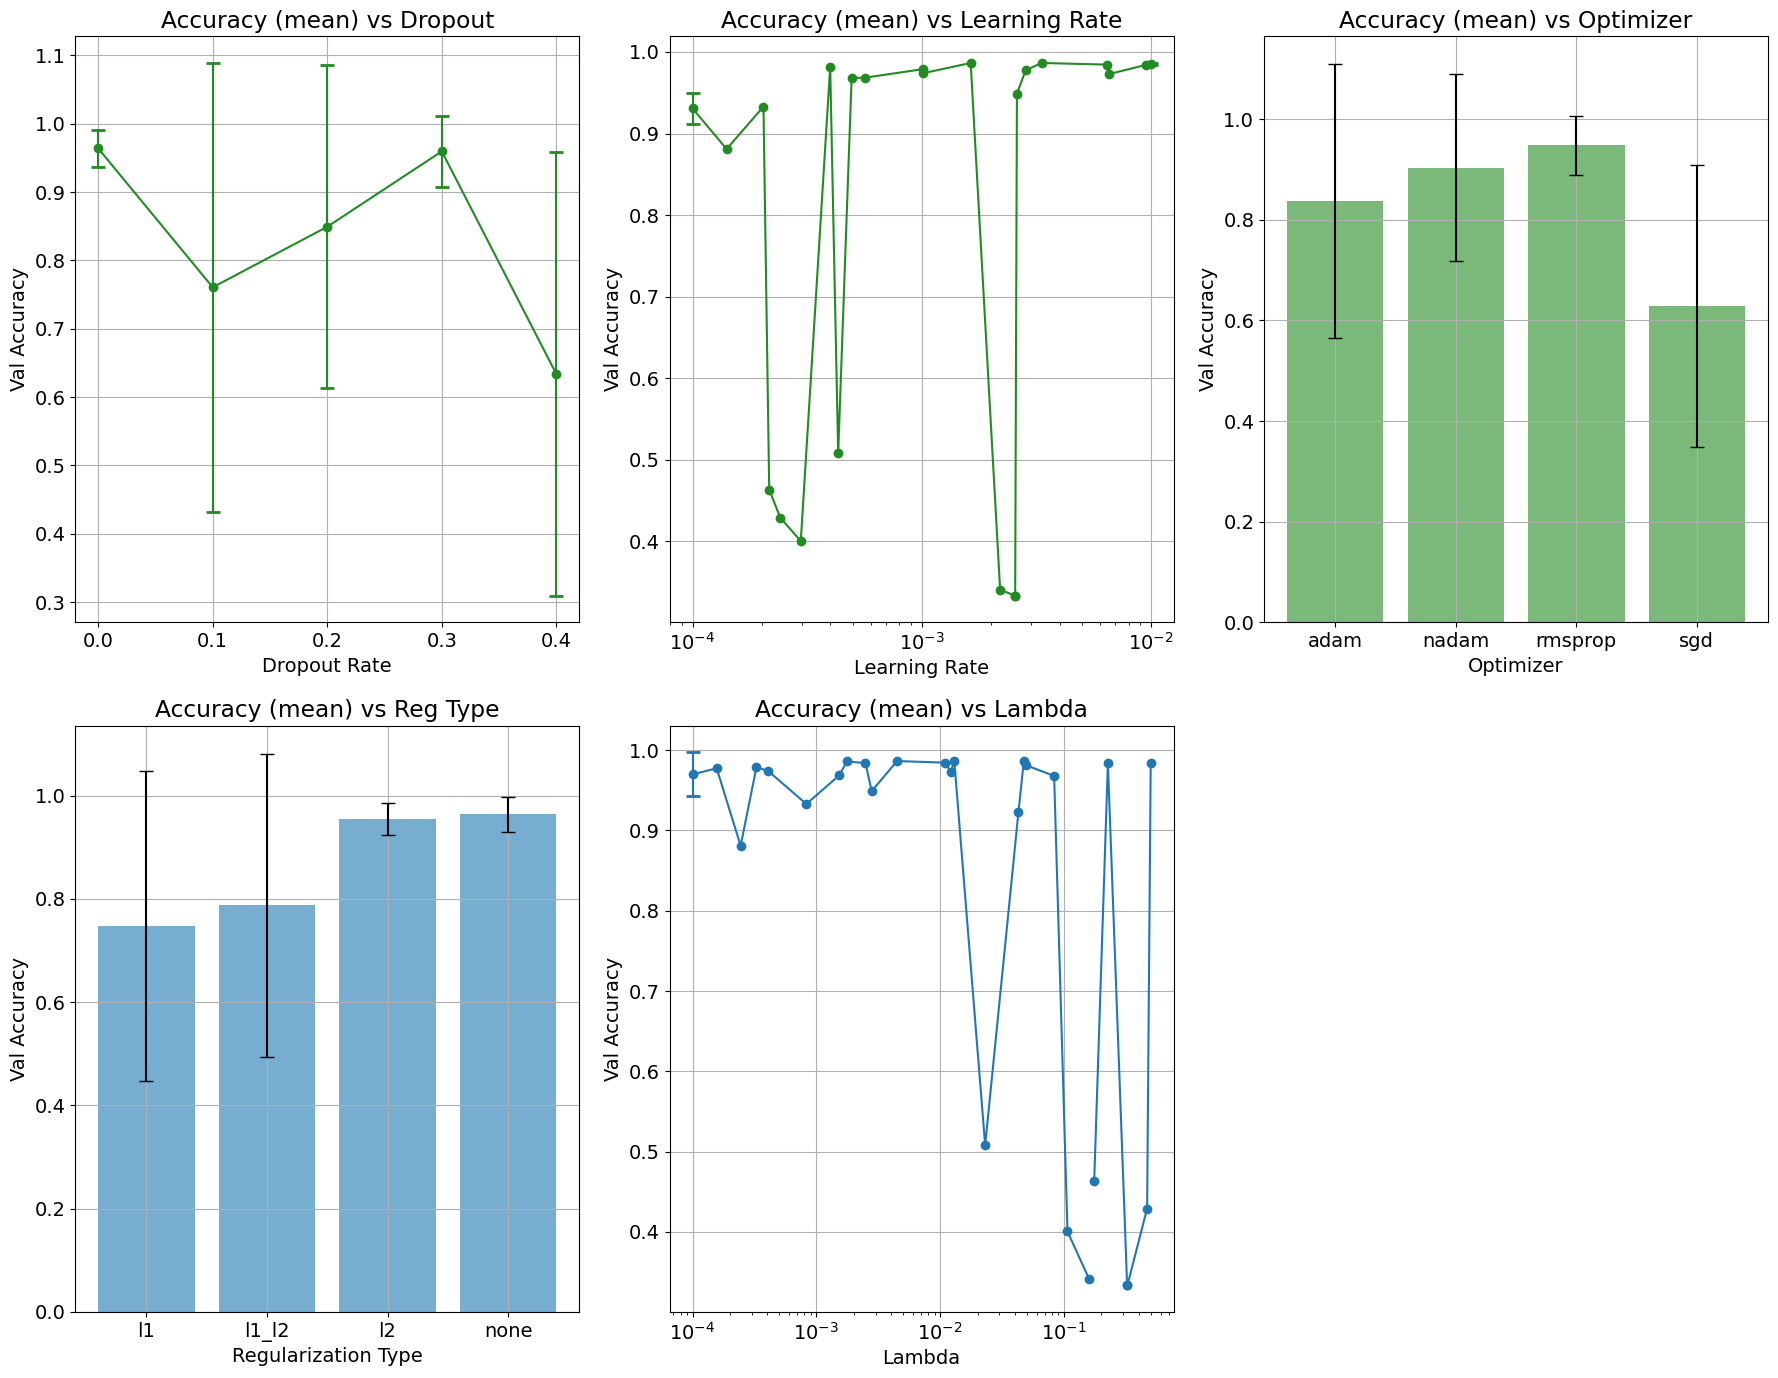

In [14]:
# First extract all results from tuner
trials = tuner.oracle.trials
results = []
for trial in trials.values():
    hp_vals = trial.hyperparameters.values
    results.append({
        "val_accuracy":  trial.score,
        "reg_type":      hp_vals.get("reg_type"),
        "lambda":        hp_vals.get("lambda"),
        "learning_rate": hp_vals.get("learning_rate"),
        "optimizer":     hp_vals.get("optimizer"),
        "dropout":       hp_vals.get("dropout_1")
    })
df = pd.DataFrame(results)

# Plot
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(18, 14))

# 1. Dropout
drop_mean = df.groupby("dropout")["val_accuracy"].mean()
drop_std  = df.groupby("dropout")["val_accuracy"].std()
ax[0][0].errorbar(drop_mean.index, drop_mean.values, yerr=drop_std.values, color = 'forestgreen',
                  marker='o', capsize=5, capthick=2, elinewidth=1.5)
ax[0][0].set_xlabel("Dropout Rate")
ax[0][0].set_ylabel("Val Accuracy")
ax[0][0].set_title("Accuracy (mean) vs Dropout")
ax[0][0].grid(True)

# 2. Learning rate
lear_mean = df.groupby("learning_rate")["val_accuracy"].mean()
lear_std  = df.groupby("learning_rate")["val_accuracy"].std()
ax[0][1].errorbar(lear_mean.index, lear_mean.values, yerr=lear_std.values, color = 'forestgreen',
                  marker='o', capsize=5, capthick=2, elinewidth=1.5)
ax[0][1].set_xscale("log")
ax[0][1].set_xlabel("Learning Rate")
ax[0][1].set_ylabel("Val Accuracy")
ax[0][1].set_title("Accuracy (mean) vs Learning Rate")
ax[0][1].grid(True)

# 3. Optimizer
opti_mean = df.groupby("optimizer")["val_accuracy"].mean()
opti_std  = df.groupby("optimizer")["val_accuracy"].std()
ax[0][2].bar(opti_mean.index, opti_mean.values, yerr=opti_std.values, color = 'forestgreen', alpha = 0.6,
             capsize=5)
ax[0][2].set_xlabel("Optimizer")
ax[0][2].set_ylabel("Val Accuracy")
ax[0][2].set_title("Accuracy (mean) vs Optimizer")
ax[0][2].grid(True)

# 4. Regularization type
regt_mean = df.groupby("reg_type")["val_accuracy"].mean()
regt_std  = df.groupby("reg_type")["val_accuracy"].std()
ax[1][0].bar(regt_mean.index, regt_mean.values, yerr=regt_std.values, alpha = 0.6,
             capsize=5)
ax[1][0].set_xlabel("Regularization Type")
ax[1][0].set_ylabel("Val Accuracy")
ax[1][0].set_title("Accuracy (mean) vs Reg Type")
ax[1][0].grid(True)

# 5. Lambda
lamb_mean = df.groupby("lambda")["val_accuracy"].mean()
lamb_std  = df.groupby("lambda")["val_accuracy"].std()
ax[1][1].errorbar(lamb_mean.index, lamb_mean.values, yerr=lamb_std.values,
                  marker='o', capsize=5, capthick=2, elinewidth=1.5)
ax[1][1].set_xscale("log")
ax[1][1].set_xlabel("Lambda")
ax[1][1].set_ylabel("Val Accuracy")
ax[1][1].set_title("Accuracy (mean) vs Lambda")
ax[1][1].grid(True)

# 6.
ax[1][2].axis("off")

plt.tight_layout()
plt.show()

In [24]:
# Get the top 2 models.
models = tuner.get_best_models(num_models=1)
best_model = models[0]
best_model.summary()

best_model.save('best_model.keras')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 50, 5)          │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 10, 5)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           306 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │            98 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            45 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 509 (1.99 KB)

 Trainable params: 509 (1.99 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
best_model = keras.models.load_model('best_model.keras')

/home/francesco/anaconda3/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
def Show_weights(model,l=0,label="model"):
    c=['r','y','c','b','m']
    m=['o','s','D','<','>']
    ms=10
    
    w = model.layers[l].get_weights()[0] # weights
    print(w.shape)
    wT=w.T
    print(wT.shape)
    M=len(wT)
    b = model.layers[l].get_weights()[1] # bias
    
    fig,AX=plt.subplots(1,2,figsize=(12,4.4))
    ax=AX[0]
    ax.axhline(0, c="k")
    ax.plot((0,))
    for i in range(M):
        ax.plot(wT[i][0],"-",c=c[i],marker=m[i],label=str(i),markersize=ms)
    ax.set_title(label+': filters of layer '+str(l))
    ax.set_xlabel('index')
    ax=AX[1]
    ax.axhline(0, c="k")
    for i in range(M):
        ax.plot((i),(b[i]),c=c[i],marker=m[i],label="filter "+str(i),markersize=ms)
    ax.set_title(label+': bias of layer '+str(l))
    ax.set_xlabel('filter nr')
    ax.set_xticks(np.arange(5))
    ax.legend()
    plt.show()
    
Show_weights(best_model,0)
Show_weights(best_model,2)

In [ ]:
BATCH_SIZE = 200
EPOCHS = 150

fit = best_model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                validation_data=(x_val, y_val),
                verbose=2, shuffle=True) 

In [ ]:
def Show_history(fit):
    fig,AX=plt.subplots(1,2,figsize=(12,5.))
    ax=AX[0] 
    ax.plot(fit.history['accuracy'],"b",label="train")
    ax.plot(fit.history['val_accuracy'],"r--",label="valid.")
    ax.plot((0,EPOCHS),(1/3,1/3),":",c="gray",label="random choice")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.set_ylim([0, 1])
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],"b",label="train")
    ax.plot(fit.history['val_loss'],"r--",label="valid.")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.set_ylim([0, 1.05*np.max(fit.history['loss'])])
    ax.legend()
    plt.show()
Show_history(fit)
Show_weights(best_model,0)
Show_weights(best_model,2)